# 04_207 · Comparación final de modelos con cuatro categorías

Este cuaderno no entrena. Reúne únicamente evaluaciones realizadas sobre validation/test 4:1 comunes y verifica que todos los resultados declaren el mismo hash de dataset. Debe ejecutarse después de los experimentos que se quieran comparar. Al comenzar en Windows, comprueba el bundle `G:\My Drive\PLN_colab_04_artifacts` y recupera hacia el workspace las métricas faltantes producidas en Colab; los archivos locales diferentes nunca se sobrescriben silenciosamente.

In [1]:
from pathlib import Path
import hashlib, json, subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'cuadernos': ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

# Recuperación automática y segura de resultados producidos en Colab.
DRIVE_BUNDLE = Path(r'G:\My Drive\PLN_colab_04_artifacts')
RECOVERY_SCRIPT = ROOT / 'scripts_auxiliares' / 'recuperar_resultados_colab_04_20x.ps1'
COLAB_RESULT_PATHS = {
    '04_202 Transformer plano': Path('resultados/metricas/transformer_plano_4/resultado.json'),
    '04_203 Transformer en cascada': Path('resultados/metricas/experimentos_jerarquicos_4/cascada_binaria_multietiqueta_4_seguros_ampliados/resultado.json'),
    '04_204 Transformer jerárquico': Path('resultados/metricas/experimentos_jerarquicos_4/transformer_jerarquico_multitarea_4/resultado.json'),
    '04_206 Qwen jerárquico': Path('resultados/metricas/qwen_jerarquico_4/resultado.json'),
}

def _sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

def _sync_state(relative):
    local, remote = ROOT / relative, DRIVE_BUNDLE / relative
    if local.is_file() and remote.is_file():
        return 'idéntico' if _sha256(local) == _sha256(remote) else 'conflicto'
    if local.is_file(): return 'solo local'
    if remote.is_file(): return 'solo Drive'
    return 'ausente'

states_before = {name: _sync_state(path) for name, path in COLAB_RESULT_PATHS.items()}
conflicts = [name for name, state in states_before.items() if state == 'conflicto']
if conflicts:
    raise RuntimeError('Resultados distintos en Drive y D: ' + ', '.join(conflicts) + '. Revíselos antes de usar -Force.')
recoverable = [name for name, state in states_before.items() if state == 'solo Drive']
if recoverable:
    if sys.platform != 'win32' or not RECOVERY_SCRIPT.is_file():
        raise RuntimeError('Hay resultados sólo en Drive, pero la recuperación automática requiere Windows y el script local.')
    command = [
        'powershell', '-NoProfile', '-ExecutionPolicy', 'Bypass', '-File', str(RECOVERY_SCRIPT),
        '-Workspace', str(ROOT), '-DriveBundle', str(DRIVE_BUNDLE), '-ComparisonOnly',
    ]
    if any(name.startswith('04_206') for name in recoverable): command.append('-IncludeQwen')
    recovery = subprocess.run(command, text=True, capture_output=True)
    if recovery.returncode != 0:
        raise RuntimeError('Falló la recuperación desde Drive:\n' + (recovery.stderr or recovery.stdout))
    print(recovery.stdout.strip())
elif not DRIVE_BUNDLE.is_dir():
    print(f'Drive no está disponible en {DRIVE_BUNDLE}; se usarán sólo resultados locales.')

sync_status = pd.DataFrame([
    {'cuaderno': name, 'antes': states_before[name], 'después': _sync_state(path)}
    for name, path in COLAB_RESULT_PATHS.items()
])
display(Markdown('### Verificación Drive → workspace'))
display(sync_status)

from scripts_auxiliares import entrenar_qwen_acoso_amenaza as q4
from scripts_auxiliares import entrenar_transformers_planos_4 as t4
from scripts_auxiliares import experimentos_jerarquicos_4 as h4
from scripts_auxiliares import experimentos_jerarquicos_clasicos_4 as c4
from scripts_auxiliares import experimentos_qwen_jerarquico_4 as qh
EXPECTED_DATASET_SHA256 = 'df2ac01183271e44b6dcfb9cb4850bd6b1ef1cd11d9fc51c881be944670ef20f'
OUTPUT_DIR = ROOT / 'resultados' / 'metricas' / 'comparacion_final_4'
FIGURE_DIR = ROOT / 'resultados' / 'figuras' / 'comparacion_final_4'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

status          : complete
copied_files    : 42
include_qwen    : False
comparison_only : True
log             : D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4\resultados\logs\sincronizacion_colab_04_20x\recuperacion_202607
                  29_072539.json


### Verificación Drive → workspace

,cuaderno,antes,después
0,04_202 Transformer plano,solo Drive,idéntico
1,04_203 Transformer en cascada,solo Drive,idéntico
2,04_204 Transformer jerárquico,solo Drive,idéntico
3,04_206 Qwen jerárquico,ausente,ausente


## 1. Descubrimiento y control del dataset

In [2]:
frames = []
hashes = []
missing = []

def add_table(path, family, structure, dataset_hash):
    path = Path(path)
    if not path.exists():
        missing.append(str(path.relative_to(ROOT)))
        return
    table = pd.read_csv(path)
    table['familia'] = family
    table['estructura'] = structure
    table['fuente'] = str(path.relative_to(ROOT))
    frames.append(table)
    hashes.append((str(path.relative_to(ROOT)), dataset_hash))

if q4.EVALUATION_PATH.exists():
    evaluation = json.loads(q4.EVALUATION_PATH.read_text(encoding='utf-8'))
    rows = []
    for split, values in evaluation['metrics'].items():
        rows.append({'model_key':'qwen4_flat','modelo':'Qwen3-0.6B LoRA plano','split':split, **{k:v for k,v in values.items() if k != 'category_recall'}})
    table = pd.DataFrame(rows)
    table['familia']='Qwen'; table['estructura']='plano'; table['fuente']=str(q4.EVALUATION_PATH.relative_to(ROOT))
    frames.append(table); hashes.append((str(q4.EVALUATION_PATH.relative_to(ROOT)), evaluation['dataset_sha256']))
else:
    missing.append(str(q4.EVALUATION_PATH.relative_to(ROOT)))

if t4.RESULT_PATH.exists():
    result=json.loads(t4.RESULT_PATH.read_text(encoding='utf-8'))
    add_table(t4.METRICS_DIR/'comparacion.csv','Transformer','plano',result['dataset']['sha256'])
else: missing.append(str(t4.RESULT_PATH.relative_to(ROOT)))

if c4.RESULT_PATH.exists():
    result=json.loads(c4.RESULT_PATH.read_text(encoding='utf-8'))
    add_table(c4.COMMON_4A1_PATH,'Clásico','plano/cascada/jerárquico',result['dataset']['balanced_dataset_sha256'])
else: missing.append(str(c4.RESULT_PATH.relative_to(ROOT)))

for key, structure in [(h4.CASCADE_EXTRA_SAFE_KEY,'cascada'),(h4.JOINT_KEY,'multitarea')]:
    result_path=h4.result_path(key)
    if result_path.exists():
        result=json.loads(result_path.read_text(encoding='utf-8'))
        add_table(h4._experiment_paths(key)['comparison'],'Transformer',structure,result['dataset']['sha256'])
    else: missing.append(str(result_path.relative_to(ROOT)))

if qh.RESULT_PATH.exists():
    result=json.loads(qh.RESULT_PATH.read_text(encoding='utf-8'))
    add_table(qh.METRICS_DIR/'comparacion.csv','Qwen','cascada/multitarea',result['dataset']['sha256'])
else: missing.append(str(qh.RESULT_PATH.relative_to(ROOT)))

bad_hashes=[item for item in hashes if item[1] != EXPECTED_DATASET_SHA256]
if bad_hashes: raise ValueError(f'Resultados con otro dataset: {bad_hashes}')
display(pd.DataFrame(hashes,columns=['fuente','dataset_sha256']))
display(Markdown('**Pendientes:** ' + (', '.join(missing) if missing else 'ninguno')))

,fuente,dataset_sha256
0,resultados\metricas\qwen3_06b_lora_acoso_amena...,df2ac01183271e44b6dcfb9cb4850bd6b1ef1cd11d9fc5...
1,resultados\metricas\transformer_plano_4\compar...,df2ac01183271e44b6dcfb9cb4850bd6b1ef1cd11d9fc5...
2,resultados\metricas\jerarquico_clasico_4\compa...,df2ac01183271e44b6dcfb9cb4850bd6b1ef1cd11d9fc5...
3,resultados\metricas\experimentos_jerarquicos_4...,df2ac01183271e44b6dcfb9cb4850bd6b1ef1cd11d9fc5...
4,resultados\metricas\experimentos_jerarquicos_4...,df2ac01183271e44b6dcfb9cb4850bd6b1ef1cd11d9fc5...


**Pendientes:** resultados\metricas\qwen_jerarquico_4\resultado.json

## 2. Tabla comparable

Se eliminan referencias duplicadas que algunos cuadernos incluyen como control. La selección global usa PR-AUC macro de validation; test sólo describe el modelo seleccionado y las demás alternativas.

In [3]:
if not frames: raise RuntimeError('Todavía no hay experimentos terminados.')
comparison=pd.concat(frames,ignore_index=True,sort=False)
required=['modelo','split','damage_pr_auc_macro','damage_f1_macro','any_damage_recall','missed_damage_as_safe']
comparison=comparison.dropna(subset=[c for c in required if c in comparison]).copy()
comparison=comparison.drop_duplicates(subset=['modelo','split'],keep='last')
comparison.to_csv(OUTPUT_DIR/'comparacion_todos_modelos_4.csv',index=False)
validation=comparison.loc[comparison['split'].eq('validation')].sort_values(['damage_pr_auc_macro','damage_f1_macro'],ascending=False)
winner=str(validation.iloc[0]['modelo'])
test=comparison.loc[comparison['split'].eq('test')].sort_values('damage_pr_auc_macro',ascending=False)
display(Markdown(f'### Ganador por validation: **{winner}**'))
display(validation[['modelo','familia','estructura','damage_pr_auc_macro','damage_f1_macro','any_damage_recall']])
display(test[['modelo','familia','estructura','damage_pr_auc_macro','damage_f1_macro','any_damage_recall','missed_damage_as_safe']])

### Ganador por validation: **Qwen3-0.6B LoRA plano**

,modelo,familia,estructura,damage_pr_auc_macro,damage_f1_macro,any_damage_recall
0,Qwen3-0.6B LoRA plano,Qwen,plano,0.543217,0.540792,0.677180
22,Multilingual E5-small (linaje MiniLM) · unión ...,Transformer,multitarea,0.520864,0.535226,0.653989
4,Multilingual E5-small (linaje MiniLM),Transformer,plano,0.504120,0.523874,0.740260
2,Paraphrase Multilingual MiniLM-L12,Transformer,plano,0.481929,0.507591,0.627087
6,SVM lineal calibrado palabra+carácter · Plano,Clásico,plano/cascada/jerárquico,0.469987,0.482623,0.622449
10,SVM lineal calibrado palabra+carácter · Cascad...,Clásico,plano/cascada/jerárquico,0.458342,0.466548,0.573284
12,Regresión logística calibrada · Plano,Clásico,plano/cascada/jerárquico,0.453105,0.467820,0.635436
16,Regresión logística calibrada · Cascada binari...,Clásico,plano/cascada/jerárquico,0.442042,0.450202,0.616883
8,SVM lineal calibrado palabra+carácter · Jerárq...,Clásico,plano/cascada/jerárquico,0.440487,0.447631,0.472171
23,Transformer jerárquico multitarea → cuatro daños,Transformer,multitarea,0.435777,0.431363,0.368275


,modelo,familia,estructura,damage_pr_auc_macro,damage_f1_macro,any_damage_recall,missed_damage_as_safe
1,Qwen3-0.6B LoRA plano,Qwen,plano,0.552014,0.534569,0.684918,328
24,Multilingual E5-small (linaje MiniLM) · unión ...,Transformer,multitarea,0.491340,0.515280,0.636888,378
3,Paraphrase Multilingual MiniLM-L12,Transformer,plano,0.482037,0.497847,0.652257,362
5,Multilingual E5-small (linaje MiniLM),Transformer,plano,0.475221,0.517196,0.740634,270
7,SVM lineal calibrado palabra+carácter · Plano,Clásico,plano/cascada/jerárquico,0.450776,0.457815,0.588857,428
11,SVM lineal calibrado palabra+carácter · Cascad...,Clásico,plano/cascada/jerárquico,0.443656,0.452284,0.537944,481
13,Regresión logística calibrada · Plano,Clásico,plano/cascada/jerárquico,0.437015,0.460651,0.620557,395
9,SVM lineal calibrado palabra+carácter · Jerárq...,Clásico,plano/cascada/jerárquico,0.428504,0.421850,0.432277,591
17,Regresión logística calibrada · Cascada binari...,Clásico,plano/cascada/jerárquico,0.427444,0.426976,0.585975,431
21,"Cascada binaria → cuatro daños, SEGURO ampliado",Transformer,cascada,0.419551,0.410083,0.360231,666


C:\Users\USER\AppData\Local\Temp\ipykernel_21896\6727361.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


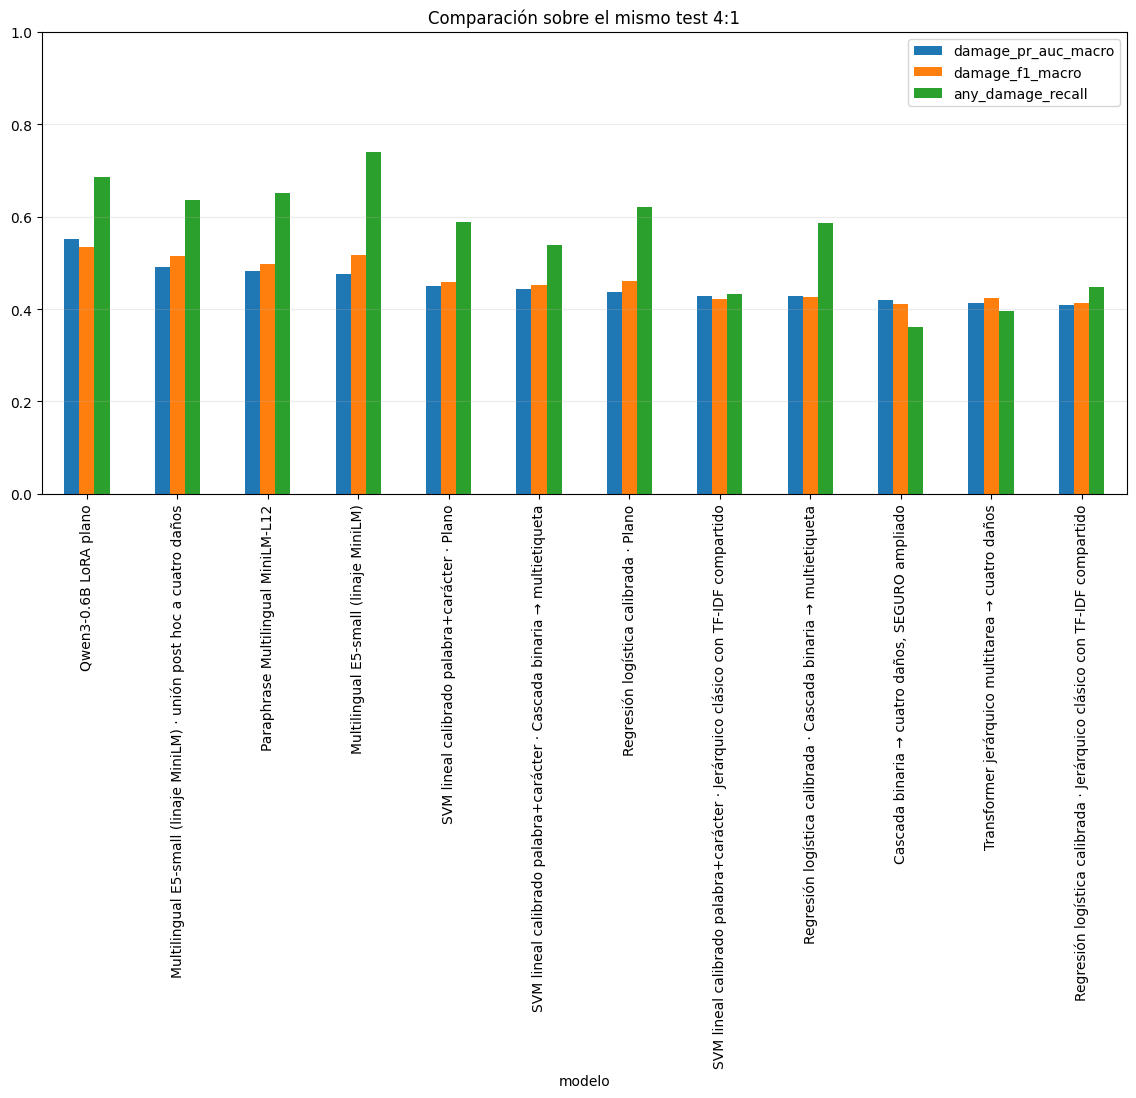

In [4]:
plot=test.set_index('modelo')[['damage_pr_auc_macro','damage_f1_macro','any_damage_recall']]
ax=plot.plot.bar(figsize=(14,6))
ax.set_ylim(0,1)
ax.set_title('Comparación sobre el mismo test 4:1')
ax.grid(axis='y',alpha=.25)
plt.tight_layout()
plt.savefig(FIGURE_DIR/'comparacion_todos_modelos_4.png',dpi=180,bbox_inches='tight')
plt.show()

## Interpretación

El ranking global por validation no sustituye los contrastes pareados de cada cuaderno jerárquico. Para producción también deben revisarse recall mínimo por categoría, falsos negativos, tasa de revisión y los intervalos por video. Ningún modelo se considera autónomo sin gold standard humano independiente y piloto prospectivo.